## BC Prequential

In [2]:
import pandas as pd

df = pd.read_csv("/Users/chiaranguyen/Desktop/SitsSCD/wrong_bc_log.csv")

df["gt_change"] = df["y_true_t-1"] != df["y_true_t"]
df["pred_change"] = df["y_pred_t-1"] != df["y_pred_t"]

df["missed_change"] = df["gt_change"] & (~df["pred_change"])
df["false_alarm"] = (~df["gt_change"]) & df["pred_change"]

# Transform patch_id, sits_id to integers
df["patch_id"] = df["patch_id"].astype("category").cat.codes
df["sits_id"] = df["sits_id"].astype("category").cat.codes

In [3]:
missed = df[df["missed_change"]]
missed

,run_id,timestamp,sits_id,patch_id,y_true_t-1,y_true_t,y_pred_t-1,y_pred_t,gt_change,pred_change,missed_change,false_alarm
9,j2tomu1g,396,50,5064,2,4,2,2,True,False,True,False
12,j2tomu1g,396,50,5063,2,4,4,4,True,False,True,False
13,j2tomu1g,396,50,5061,2,4,4,4,True,False,True,False
14,j2tomu1g,396,50,5048,2,4,4,4,True,False,True,False
15,j2tomu1g,396,50,5059,2,4,2,2,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
30604,j2tomu1g,699,25,2458,2,4,2,2,True,False,True,False
30607,j2tomu1g,699,25,2466,4,2,4,4,True,False,True,False
30613,j2tomu1g,699,25,2502,2,4,4,4,True,False,True,False
30620,j2tomu1g,699,25,2404,2,4,2,2,True,False,True,False


In [4]:
# False negative: patch changed but model missed it
missed_by_patch = (
    df[df["missed_change"]]
    .groupby("patch_id")
    .size()
    .sort_values(ascending=False)
)
missed_by_patch

patch_id
1957    6
5805    6
1941    6
50      6
685     6
       ..
2908    1
2909    1
2910    1
2911    1
8293    1
Length: 3155, dtype: int64

In [5]:
missed_by_sits = (
    df[df["missed_change"]]
    .groupby("sits_id")
    .size()
    .sort_values(ascending=False)
)
missed_by_sits

sits_id
20    251
21    230
33    209
69    206
17    166
     ... 
15      3
13      2
61      1
38      1
42      1
Length: 72, dtype: int64

In [11]:
false = df[df["false_alarm"]]
false

,run_id,timestamp,sits_id,patch_id,y_true_t-1,y_true_t,y_pred_t-1,y_pred_t,gt_change,pred_change,missed_change,false_alarm
0,j2tomu1g,396,50,5072,2,2,2,4,False,True,False,True
1,j2tomu1g,396,50,5065,2,2,2,4,False,True,False,True
2,j2tomu1g,396,50,5079,2,2,2,4,False,True,False,True
3,j2tomu1g,396,50,5076,5,5,2,5,False,True,False,True
4,j2tomu1g,396,50,5080,4,4,2,4,False,True,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...
30623,j2tomu1g,699,25,2438,4,4,4,2,False,True,False,True
30624,j2tomu1g,699,25,2450,4,4,2,4,False,True,False,True
30625,j2tomu1g,699,25,2453,4,4,4,2,False,True,False,True
30627,j2tomu1g,699,25,2430,4,4,4,2,False,True,False,True


In [12]:
# False positive: patch did not change but model predicted change
false_by_patch = (
    df[df["false_alarm"]]
    .groupby("patch_id")
    .size()
    .sort_values(ascending=False)
)
false_by_patch

patch_id
6320    11
1114    11
3816    11
6345    11
1714    10
        ..
3275     1
3276     1
1346     1
387      1
1905     1
Length: 7798, dtype: int64

In [13]:
false_by_sits = (
    df[df["false_alarm"]]
    .groupby("sits_id")
    .size()
    .sort_values(ascending=False)
)
false_by_sits

sits_id
38    991
58    980
67    913
74    905
53    889
     ... 
71     37
73     31
44     25
42     16
46     12
Length: 75, dtype: int64

In [6]:
CLASS_NAMES = ["impervi", "agricult", "forest", "wetlands", "soil", "water"]
class_map = dict(enumerate(CLASS_NAMES))

missed_transitions = (
    df[df["missed_change"]]
    .groupby(["y_true_t-1", "y_true_t"])
    .size()
    .sort_values(ascending=False)
)

missed_transitions_df = (
    missed_transitions
    .reset_index(name="count")
)

missed_transitions_df["from_class"] = missed_transitions_df["y_true_t-1"].map(class_map)
missed_transitions_df["to_class"]   = missed_transitions_df["y_true_t"].map(class_map)

missed_transitions_df = missed_transitions_df[
    ["from_class", "to_class", "count"]
]

missed_transitions_df

,from_class,to_class,count
0,soil,forest,1708
1,forest,soil,1654
2,soil,water,168
3,agricult,soil,151
4,soil,agricult,145
5,water,soil,135
6,soil,impervi,127
7,impervi,soil,102
8,water,wetlands,90
9,forest,water,79


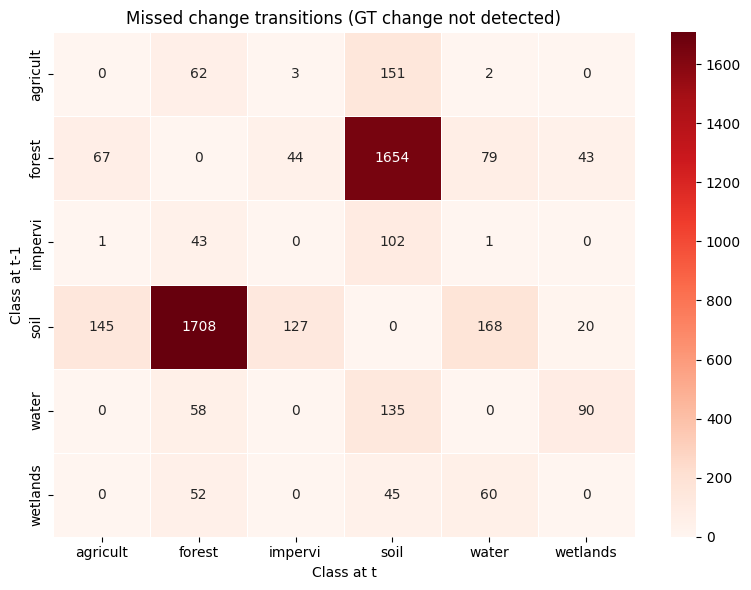

In [8]:
# righe = classe precedente, colonne = classe attuale
heatmap_df = missed_transitions_df.pivot(
    index="from_class",
    columns="to_class",
    values="count"
).fillna(0)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.heatmap(
    heatmap_df,
    annot=True,
    fmt=".0f",
    cmap="Reds",
    linewidths=0.5
)

plt.xlabel("Class at t")
plt.ylabel("Class at t-1")
plt.title("Missed change transitions (GT change not detected)")
plt.tight_layout()
plt.show()

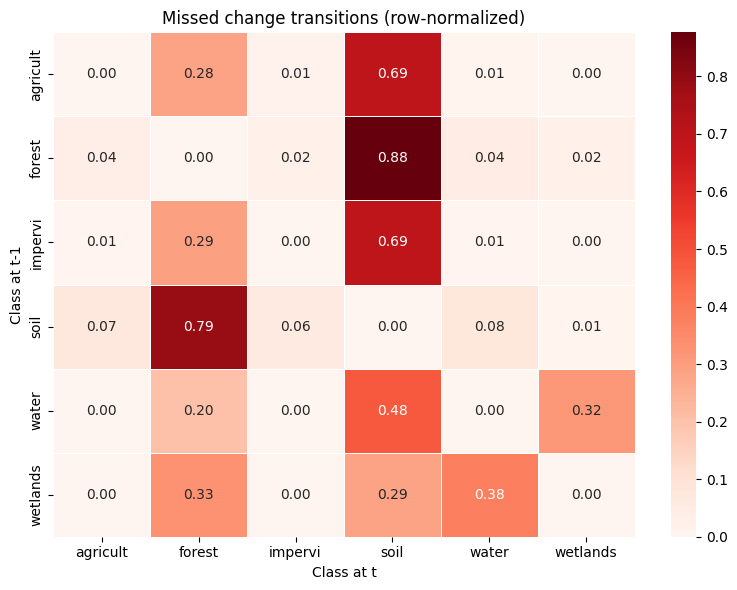

In [10]:
heatmap_norm = heatmap_df.div(heatmap_df.sum(axis=1), axis=0)

plt.figure(figsize=(8, 6))
sns.heatmap(
    heatmap_norm,
    annot=True,
    fmt=".2f",
    cmap="Reds",
    linewidths=0.5
)

plt.xlabel("Class at t")
plt.ylabel("Class at t-1")
plt.title("Missed change transitions (row-normalized)")
plt.tight_layout()
plt.show()

In [19]:
CLASS_NAMES = ["impervi", "agricult", "forest", "wetlands", "soil", "water"]
class_map = dict(enumerate(CLASS_NAMES))

false_pred_transitions = (
    df[df["false_alarm"]]
    .groupby(["y_pred_t-1", "y_pred_t"])
    .size()
    .sort_values(ascending=False)
)

false_pred_transitions_df = (
    false_pred_transitions
    .reset_index(name="count")
)   

false_pred_transitions_df["from_class"] = false_pred_transitions_df["y_pred_t-1"].map(class_map)
false_pred_transitions_df["to_class"]   = false_pred_transitions_df["y_pred_t"].map(class_map)

false_pred_transitions_df = false_pred_transitions_df[
    ["from_class", "to_class", "count"]
]

print("Max false predicted transitions:", false_pred_transitions_df["count"].max())
false_pred_transitions_df

Max false predicted transitions: 6121


,from_class,to_class,count
0,forest,soil,6121
1,soil,forest,5911
2,agricult,forest,2779
3,forest,agricult,2518
4,soil,agricult,1501
5,agricult,soil,1474
6,water,forest,1008
7,forest,water,988
8,impervi,soil,680
9,soil,impervi,639


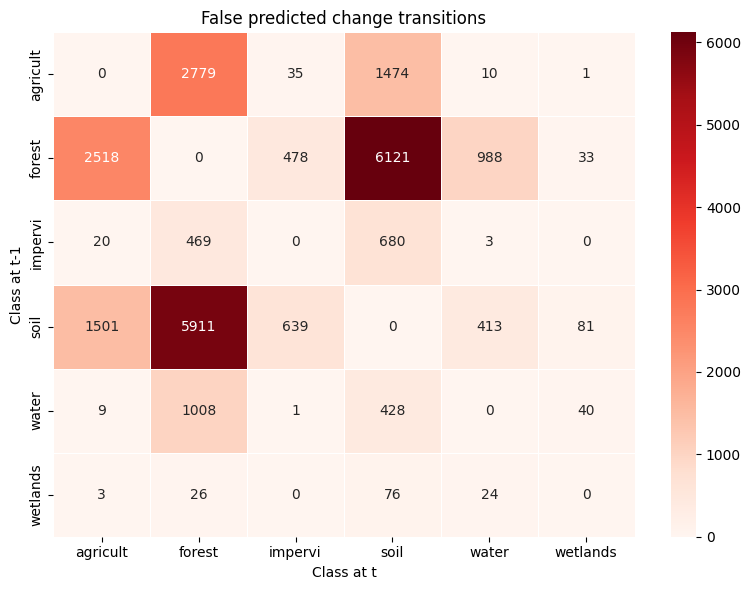

In [20]:
# righe = classe precedente, colonne = classe attuale
false_pred_heatmap_df = false_pred_transitions_df.pivot(
    index="from_class",
    columns="to_class",
    values="count"
).fillna(0)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.heatmap(
    heatmap_df,
    annot=True,
    fmt=".0f",
    cmap="Reds",
    linewidths=0.5
)

plt.xlabel("Class at t")
plt.ylabel("Class at t-1")
plt.title("False predicted change transitions")
plt.tight_layout()
plt.show()

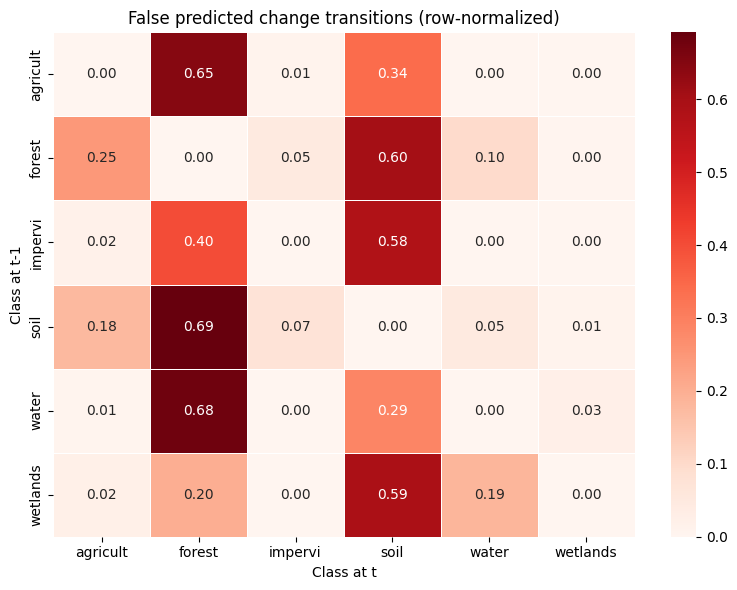

In [21]:
false_pred_heatmap_norm = false_pred_heatmap_df.div(false_pred_heatmap_df.sum(axis=1), axis=0)

plt.figure(figsize=(8, 6))
sns.heatmap(
    false_pred_heatmap_norm,
    annot=True,
    fmt=".2f",
    cmap="Reds",
    linewidths=0.5
)

plt.xlabel("Class at t")
plt.ylabel("Class at t-1")
plt.title("False predicted change transitions (row-normalized)")
plt.tight_layout()
plt.show()

In [ ]:
CLASS_NAMES = ["impervi", "agricult", "forest", "wetlands", "soil", "water"]
class_map = dict(enumerate(CLASS_NAMES))

patch_class_failures = (
    df[df["missed_change"]]
    .groupby(["patch_id", "y_true_t-1", "y_true_t"])
    .size()
    .sort_values(ascending=False)
)

patch_class_failures_df = (
    patch_class_failures
    .reset_index(name="count")
)   

patch_class_failures_df["from_class"] = patch_class_failures_df["y_true_t-1"].map(class_map)
patch_class_failures_df["to_class"]   = patch_class_failures_df["y_true_t"].map(class_map)
patch_class_failures_df = patch_class_failures_df[
    ["patch_id", "from_class", "to_class", "count"]
]

patch_class_failures_df

Patch with max class failures: 3


,patch_id,from_class,to_class,count
0,6456,soil,forest,3
1,1979,soil,agricult,3
2,4208,water,wetlands,3
3,5805,forest,soil,3
4,7511,impervi,soil,3
...,...,...,...,...
4473,2255,soil,forest,1
4474,2256,forest,soil,1
4475,2256,soil,forest,1
4476,2257,forest,soil,1


In [38]:
CLASS_NAMES = ["impervi", "agricult", "forest", "wetlands", "soil", "water"]
class_map = dict(enumerate(CLASS_NAMES))

sits_class_failures = (
    df[df["missed_change"]]
    .groupby(["sits_id", "y_true_t-1", "y_true_t"])
    .size()
    .sort_values(ascending=False)
)   

sits_class_failures_df = (
    sits_class_failures
    .reset_index(name="count")
)   

sits_class_failures_df["from_class"] = sits_class_failures_df["y_true_t-1"].map(class_map)
sits_class_failures_df["to_class"]   = sits_class_failures_df["y_true_t"].map(class_map)
sits_class_failures_df = sits_class_failures_df[
    ["sits_id", "from_class", "to_class", "count"]
]
sits_class_failures_df

,sits_id,from_class,to_class,count
0,21,forest,soil,121
1,6,forest,soil,118
2,20,agricult,soil,113
3,33,forest,soil,108
4,14,soil,forest,108
...,...,...,...,...
320,10,water,forest,1
321,52,soil,impervi,1
322,62,soil,water,1
323,53,agricult,forest,1


## SC Prequential

In [18]:
import pandas as pd

df_sc = pd.read_csv("/Users/chiaranguyen/Desktop/SitsSCD/wrong_sc_log.csv")

# Transform patch_id, sits_id to integers
df_sc["patch_id"] = df_sc["patch_id"].astype("category").cat.codes
df_sc["sits_id"] = df_sc["sits_id"].astype("category").cat.codes

df_sc["gt_change"] = df_sc["y_true_t-1"] != df_sc["y_true_t"]
df_sc["pred_change"] = df_sc["y_pred_t-1"] != df_sc["y_pred_t"]

df_sc["missed_change"] = df_sc["gt_change"] & (~df_sc["pred_change"])
df_sc["real_change"] = df_sc["gt_change"] & df_sc["pred_change"]

KeyError: 'y_true_t-1'

## BC Test Only

In [1]:
import pandas as pd

df = pd.read_csv("/Users/chiaranguyen/Desktop/SitsSCD/wrong_bc_log_test.csv")

df["gt_change"] = df["y_true_t-1"] != df["y_true_t"]
df["pred_change"] = df["y_pred_t-1"] != df["y_pred_t"]

df["missed_change"] = df["gt_change"] & (~df["pred_change"])
df["false_alarm"] = (~df["gt_change"]) & df["pred_change"]

# Transform patch_id, sits_id to integers
df["patch_id"] = df["patch_id"].astype("category").cat.codes
df["sits_id"] = df["sits_id"].astype("category").cat.codes

In [2]:
missed = df[df["missed_change"]]
missed

,run_id,timestamp,sits_id,patch_id,y_true_t-1,y_true_t,y_pred_t-1,y_pred_t,gt_change,pred_change,missed_change,false_alarm
0,ws02iyih,396,50,5437,2,4,2,2,True,False,True,False
3,ws02iyih,396,50,5433,2,4,2,2,True,False,True,False
4,ws02iyih,396,50,5432,2,4,4,4,True,False,True,False
5,ws02iyih,396,50,5430,2,4,4,4,True,False,True,False
6,ws02iyih,396,50,5455,2,4,2,2,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
27990,ws02iyih,699,25,2813,2,4,4,4,True,False,True,False
27993,ws02iyih,699,25,2820,2,4,4,4,True,False,True,False
28002,ws02iyih,699,25,2716,2,4,2,2,True,False,True,False
28013,ws02iyih,699,25,2742,2,4,2,2,True,False,True,False


In [3]:
# False negative: patch changed but model missed it
missed_by_patch = (
    df[df["missed_change"]]
    .groupby("patch_id")
    .size()
    .sort_values(ascending=False)
)
missed_by_patch

patch_id
1102    7
2773    7
6118    6
2170    6
2171    6
       ..
4706    1
1804    1
1805    1
1806    1
5355    1
Length: 3125, dtype: int64

In [4]:
missed_by_sits = (
    df[df["missed_change"]]
    .groupby("sits_id")
    .size()
    .sort_values(ascending=False)
)
missed_by_sits

sits_id
20    276
33    237
21    204
14    174
4     173
     ... 
71      5
13      2
15      2
61      1
42      1
Length: 71, dtype: int64

In [5]:
false = df[df["false_alarm"]]
false

,run_id,timestamp,sits_id,patch_id,y_true_t-1,y_true_t,y_pred_t-1,y_pred_t,gt_change,pred_change,missed_change,false_alarm
1,ws02iyih,396,50,5446,2,2,0,4,False,True,False,True
2,ws02iyih,396,50,5451,4,4,2,4,False,True,False,True
7,ws02iyih,396,50,5421,4,4,4,2,False,True,False,True
9,ws02iyih,396,50,5423,4,4,0,4,False,True,False,True
10,ws02iyih,396,50,5425,4,4,4,2,False,True,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...
28016,ws02iyih,699,25,2747,4,4,2,4,False,True,False,True
28017,ws02iyih,699,25,2748,4,4,2,4,False,True,False,True
28018,ws02iyih,699,25,2749,4,4,2,4,False,True,False,True
28019,ws02iyih,699,25,2753,2,2,2,4,False,True,False,True


In [6]:
# False positive: patch did not change but model predicted change
false_by_patch = (
    df[df["false_alarm"]]
    .groupby("patch_id")
    .size()
    .sort_values(ascending=False)
)
false_by_patch

patch_id
8263    10
8248    10
8159    10
6983    10
8419     9
        ..
2261     1
2262     1
2263     1
6087     1
2226     1
Length: 7568, dtype: int64

In [7]:
false_by_sits = (
    df[df["false_alarm"]]
    .groupby("sits_id")
    .size()
    .sort_values(ascending=False)
)
false_by_sits

sits_id
2     838
70    726
17    608
67    602
53    588
     ... 
23     17
19     17
73      8
46      5
71      1
Length: 75, dtype: int64

In [8]:
CLASS_NAMES = ["impervi", "agricult", "forest", "wetlands", "soil", "water"]
class_map = dict(enumerate(CLASS_NAMES))

missed_transitions = (
    df[df["missed_change"]]
    .groupby(["y_true_t-1", "y_true_t"])
    .size()
    .sort_values(ascending=False)
)

missed_transitions_df = (
    missed_transitions
    .reset_index(name="count")
)

missed_transitions_df["from_class"] = missed_transitions_df["y_true_t-1"].map(class_map)
missed_transitions_df["to_class"]   = missed_transitions_df["y_true_t"].map(class_map)

missed_transitions_df = missed_transitions_df[
    ["from_class", "to_class", "count"]
]

missed_transitions_df

,from_class,to_class,count
0,soil,forest,1763
1,forest,soil,1644
2,water,soil,196
3,soil,water,192
4,soil,agricult,181
5,agricult,soil,160
6,soil,impervi,126
7,impervi,soil,125
8,water,wetlands,98
9,agricult,forest,96


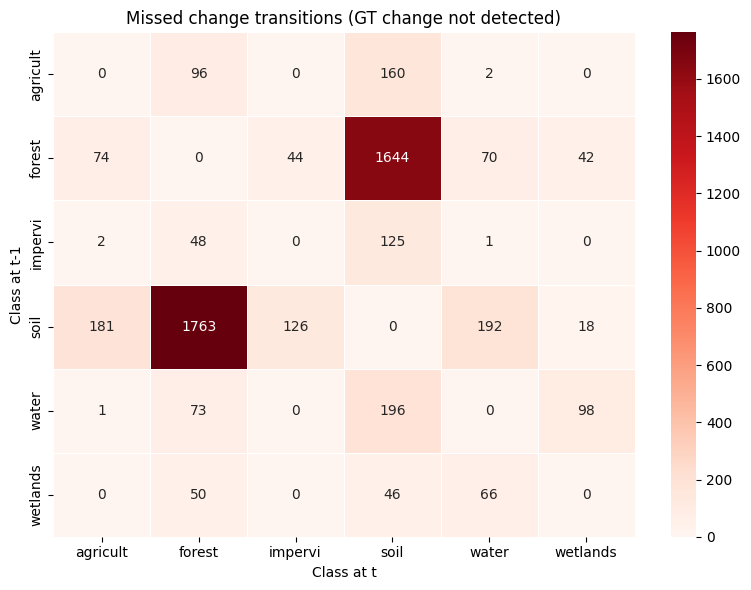

In [9]:
# righe = classe precedente, colonne = classe attuale
heatmap_df = missed_transitions_df.pivot(
    index="from_class",
    columns="to_class",
    values="count"
).fillna(0)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.heatmap(
    heatmap_df,
    annot=True,
    fmt=".0f",
    cmap="Reds",
    linewidths=0.5
)

plt.xlabel("Class at t")
plt.ylabel("Class at t-1")
plt.title("Missed change transitions (GT change not detected)")
plt.tight_layout()
plt.show()

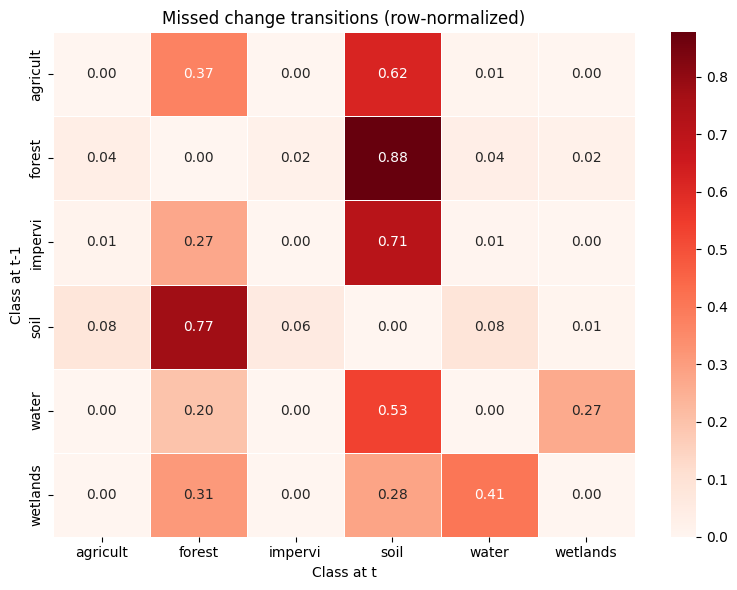

In [10]:
heatmap_norm = heatmap_df.div(heatmap_df.sum(axis=1), axis=0)

plt.figure(figsize=(8, 6))
sns.heatmap(
    heatmap_norm,
    annot=True,
    fmt=".2f",
    cmap="Reds",
    linewidths=0.5
)

plt.xlabel("Class at t")
plt.ylabel("Class at t-1")
plt.title("Missed change transitions (row-normalized)")
plt.tight_layout()
plt.show()

In [11]:
CLASS_NAMES = ["impervi", "agricult", "forest", "wetlands", "soil", "water"]
class_map = dict(enumerate(CLASS_NAMES))

false_pred_transitions = (
    df[df["false_alarm"]]
    .groupby(["y_pred_t-1", "y_pred_t"])
    .size()
    .sort_values(ascending=False)
)

false_pred_transitions_df = (
    false_pred_transitions
    .reset_index(name="count")
)   

false_pred_transitions_df["from_class"] = false_pred_transitions_df["y_pred_t-1"].map(class_map)
false_pred_transitions_df["to_class"]   = false_pred_transitions_df["y_pred_t"].map(class_map)

false_pred_transitions_df = false_pred_transitions_df[
    ["from_class", "to_class", "count"]
]

print("Max false predicted transitions:", false_pred_transitions_df["count"].max())
false_pred_transitions_df

Max false predicted transitions: 5623


,from_class,to_class,count
0,soil,forest,5623
1,forest,soil,5463
2,forest,agricult,2405
3,agricult,forest,2337
4,agricult,soil,1397
5,soil,agricult,1301
6,forest,water,1013
7,water,forest,964
8,soil,water,380
9,water,soil,371


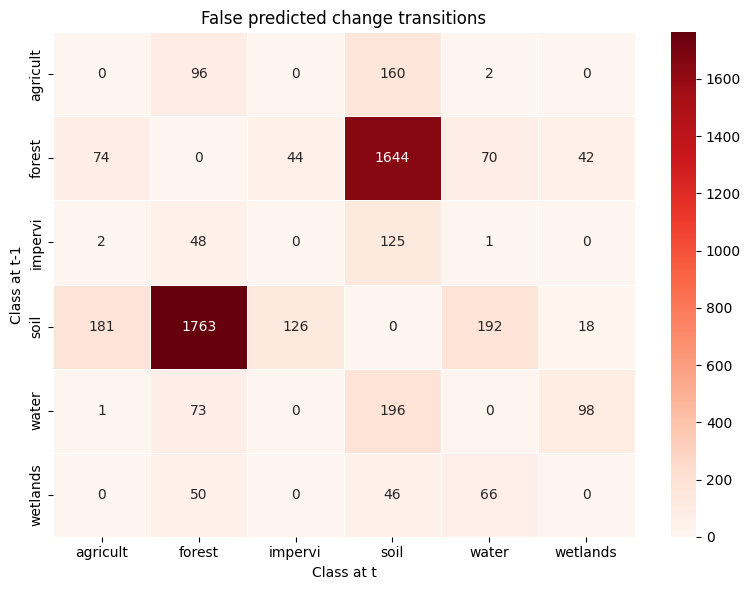

In [12]:
# righe = classe precedente, colonne = classe attuale
false_pred_heatmap_df = false_pred_transitions_df.pivot(
    index="from_class",
    columns="to_class",
    values="count"
).fillna(0)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.heatmap(
    heatmap_df,
    annot=True,
    fmt=".0f",
    cmap="Reds",
    linewidths=0.5
)

plt.xlabel("Class at t")
plt.ylabel("Class at t-1")
plt.title("False predicted change transitions")
plt.tight_layout()
plt.show()

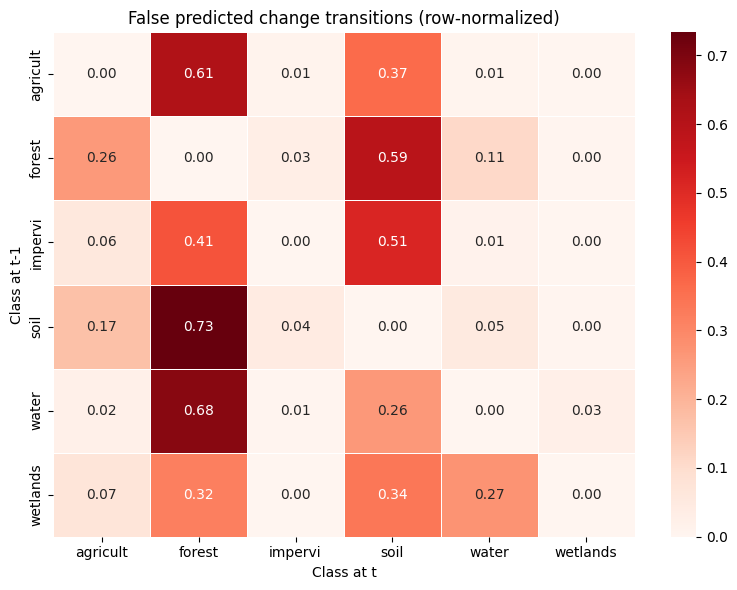

In [13]:
false_pred_heatmap_norm = false_pred_heatmap_df.div(false_pred_heatmap_df.sum(axis=1), axis=0)

plt.figure(figsize=(8, 6))
sns.heatmap(
    false_pred_heatmap_norm,
    annot=True,
    fmt=".2f",
    cmap="Reds",
    linewidths=0.5
)

plt.xlabel("Class at t")
plt.ylabel("Class at t-1")
plt.title("False predicted change transitions (row-normalized)")
plt.tight_layout()
plt.show()

In [14]:
CLASS_NAMES = ["impervi", "agricult", "forest", "wetlands", "soil", "water"]
class_map = dict(enumerate(CLASS_NAMES))

patch_class_failures = (
    df[df["missed_change"]]
    .groupby(["patch_id", "y_true_t-1", "y_true_t"])
    .size()
    .sort_values(ascending=False)
)

patch_class_failures_df = (
    patch_class_failures
    .reset_index(name="count")
)   

patch_class_failures_df["from_class"] = patch_class_failures_df["y_true_t-1"].map(class_map)
patch_class_failures_df["to_class"]   = patch_class_failures_df["y_true_t"].map(class_map)
patch_class_failures_df = patch_class_failures_df[
    ["patch_id", "from_class", "to_class", "count"]
]

patch_class_failures_df

,patch_id,from_class,to_class,count
0,6805,forest,soil,4
1,2171,agricult,soil,4
2,2773,soil,forest,4
3,2315,soil,agricult,3
4,2742,forest,soil,3
...,...,...,...,...
4650,2571,soil,forest,1
4651,2572,forest,soil,1
4652,2572,soil,forest,1
4653,2573,forest,soil,1


In [15]:
CLASS_NAMES = ["impervi", "agricult", "forest", "wetlands", "soil", "water"]
class_map = dict(enumerate(CLASS_NAMES))

sits_class_failures = (
    df[df["missed_change"]]
    .groupby(["sits_id", "y_true_t-1", "y_true_t"])
    .size()
    .sort_values(ascending=False)
)   

sits_class_failures_df = (
    sits_class_failures
    .reset_index(name="count")
)   

sits_class_failures_df["from_class"] = sits_class_failures_df["y_true_t-1"].map(class_map)
sits_class_failures_df["to_class"]   = sits_class_failures_df["y_true_t"].map(class_map)
sits_class_failures_df = sits_class_failures_df[
    ["sits_id", "from_class", "to_class", "count"]
]
sits_class_failures_df

,sits_id,from_class,to_class,count
0,33,soil,forest,167
1,6,forest,soil,113
2,20,agricult,soil,97
3,20,soil,agricult,95
4,14,forest,soil,94
...,...,...,...,...
335,55,forest,agricult,1
336,55,water,forest,1
337,63,forest,impervi,1
338,18,water,soil,1


## SC Test Only

In [34]:
import pandas as pd

df_sc = pd.read_csv("/Users/chiaranguyen/Desktop/SitsSCD/wrong_sc_log_test.csv")

print("Total records:", len(df_sc))

# Transform patch_id, sits_id to integers
df_sc["patch_id"] = df_sc["patch_id"].astype("category").cat.codes
df_sc["sits_id"] = df_sc["sits_id"].astype("category").cat.codes

df_sc["pred_change"] = df_sc["y_pred_t-1"] != df_sc["y_pred_t"]

Total records: 4033


In [35]:
# Number of undetected changes
undetected_changes = df_sc[~df_sc["pred_change"]]
detected_changes = df_sc[df_sc["pred_change"]]
num_undetected_changes = len(undetected_changes)
print("Number of undetected changes:", num_undetected_changes)
print("Number of changes detected:", len(detected_changes))

Number of undetected changes: 2831
Number of changes detected: 1202


In [36]:
detected_changes

,run_id,timestamp,sits_id,patch_id,y_true_t-1,y_true_t,y_pred_t-1,y_pred_t,pred_change
3,ws02iyih,396,47,1993,2,4,4,2,True
10,ws02iyih,396,47,2034,2,4,5,2,True
16,ws02iyih,396,47,2029,2,4,4,2,True
24,ws02iyih,396,47,2058,2,4,4,2,True
32,ws02iyih,396,44,1808,3,5,5,4,True
...,...,...,...,...,...,...,...,...,...
4016,ws02iyih,699,19,937,2,4,2,1,True
4021,ws02iyih,699,25,1232,2,0,0,2,True
4022,ws02iyih,699,25,1227,0,2,2,1,True
4024,ws02iyih,699,22,1127,2,4,4,2,True


In [37]:
detected_changes_by_patch = (
    df_sc[df_sc["pred_change"]]
    .groupby("patch_id")
    .size()
    .sort_values(ascending=False)
)
detected_changes_by_patch = detected_changes_by_patch.reset_index(name="count")
detected_changes_by_patch

,patch_id,count
0,865,5
1,1675,5
2,2696,4
3,2388,4
4,952,4
...,...,...
990,997,1
991,1001,1
992,1004,1
993,1008,1


In [38]:
detected_changes_by_sits = (
    df_sc[df_sc["pred_change"]]
    .groupby("sits_id")
    .size()
    .sort_values(ascending=False)
)
detected_changes_by_sits = detected_changes_by_sits.reset_index(name="count")
detected_changes_by_sits

,sits_id,count
0,19,144
1,65,63
2,16,57
3,13,54
4,20,52
...,...,...
56,28,2
57,30,1
58,37,1
59,18,1


In [39]:
CLASS_NAMES = ["impervi", "agricult", "forest", "wetlands", "soil", "water"]
class_map = dict(enumerate(CLASS_NAMES))

missed_classification = (
    df_sc[df_sc["pred_change"]]
    .groupby(["y_true_t-1", "y_true_t"])
    .size()
    .sort_values(ascending=False)
)

missed_classification_df = (
    missed_classification
    .reset_index(name="count")
)

missed_classification_df["from_class"] = missed_classification_df["y_true_t-1"].map(class_map)
missed_classification_df["to_class"]   = missed_classification_df["y_true_t"].map(class_map)

missed_classification_df = missed_classification_df[
    ["from_class", "to_class", "count"]
]

missed_classification_df

,from_class,to_class,count
0,soil,forest,354
1,forest,soil,285
2,agricult,soil,98
3,water,soil,74
4,water,wetlands,74
5,soil,water,48
6,soil,impervi,44
7,soil,agricult,41
8,forest,agricult,38
9,forest,impervi,24


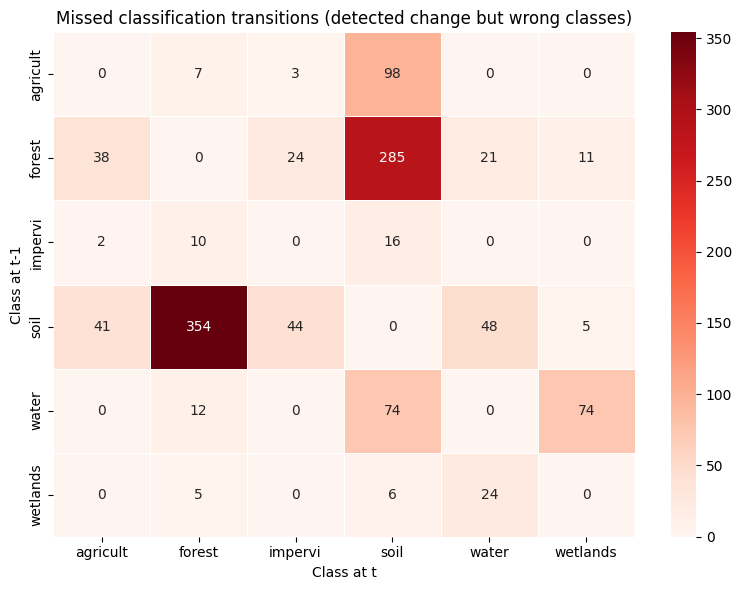

In [42]:
# righe = classe precedente, colonne = classe attuale
heatmap_df = missed_classification_df.pivot(
    index="from_class",
    columns="to_class",
    values="count"
).fillna(0)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.heatmap(
    heatmap_df,
    annot=True,
    fmt=".0f",
    cmap="Reds",
    linewidths=0.5
)

plt.xlabel("Class at t")
plt.ylabel("Class at t-1")
plt.title("Missed classification transitions (detected change but wrong classes)")
plt.tight_layout()
plt.show()

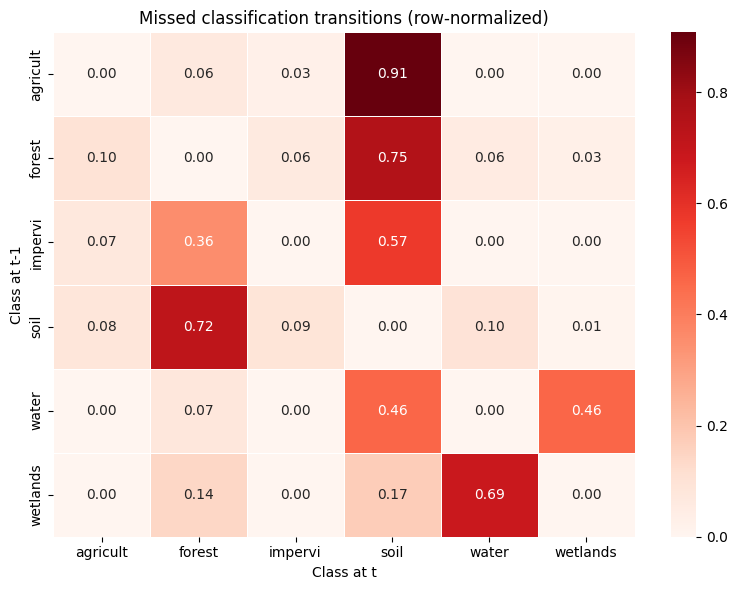

In [43]:
heatmap_norm = heatmap_df.div(heatmap_df.sum(axis=1), axis=0)

plt.figure(figsize=(8, 6))
sns.heatmap(
    heatmap_norm,
    annot=True,
    fmt=".2f",
    cmap="Reds",
    linewidths=0.5
)

plt.xlabel("Class at t")
plt.ylabel("Class at t-1")
plt.title("Missed classification transitions (row-normalized)")
plt.tight_layout()
plt.show()

In [44]:
CLASS_NAMES = ["impervi", "agricult", "forest", "wetlands", "soil", "water"]
class_map = dict(enumerate(CLASS_NAMES))

patch_class_failures = (
    df_sc[df_sc["pred_change"]]
    .groupby(["patch_id", "y_true_t-1", "y_true_t"])
    .size()
    .sort_values(ascending=False)
)

patch_class_failures_df = (
    patch_class_failures
    .reset_index(name="count")
)   

patch_class_failures_df["from_class"] = patch_class_failures_df["y_true_t-1"].map(class_map)
patch_class_failures_df["to_class"]   = patch_class_failures_df["y_true_t"].map(class_map)
patch_class_failures_df = patch_class_failures_df[
    ["patch_id", "from_class", "to_class", "count"]
]

patch_class_failures_df

,patch_id,from_class,to_class,count
0,952,agricult,soil,3
1,1668,water,wetlands,3
2,1675,water,wetlands,3
3,2253,water,soil,3
4,2388,agricult,impervi,2
...,...,...,...,...
1147,917,forest,agricult,1
1148,917,soil,forest,1
1149,923,agricult,soil,1
1150,927,agricult,soil,1


In [45]:
CLASS_NAMES = ["impervi", "agricult", "forest", "wetlands", "soil", "water"]
class_map = dict(enumerate(CLASS_NAMES))

sits_class_failures = (
    df_sc[df_sc["pred_change"]]
    .groupby(["sits_id", "y_true_t-1", "y_true_t"])
    .size()
    .sort_values(ascending=False)
)   

sits_class_failures_df = (
    sits_class_failures
    .reset_index(name="count")
)   

sits_class_failures_df["from_class"] = sits_class_failures_df["y_true_t-1"].map(class_map)
sits_class_failures_df["to_class"]   = sits_class_failures_df["y_true_t"].map(class_map)
sits_class_failures_df = sits_class_failures_df[
    ["sits_id", "from_class", "to_class", "count"]
]
sits_class_failures_df

,sits_id,from_class,to_class,count
0,19,agricult,soil,85
1,16,forest,soil,49
2,13,soil,forest,48
3,65,soil,forest,40
4,2,soil,forest,31
...,...,...,...,...
209,17,agricult,forest,1
210,61,impervi,soil,1
211,61,forest,impervi,1
212,15,water,soil,1


In [47]:
sc_over_time_bc = (
    df_sc
    .groupby(["timestamp", "pred_change"])
    .size()
    .reset_index(name="count")
)
sc_over_time_bc

,timestamp,pred_change,count
0,396,False,290
1,396,True,118
2,424,False,255
3,424,True,106
4,455,False,343
5,455,True,137
6,485,False,274
7,485,True,158
8,516,False,320
9,516,True,187


In [49]:
df_sc["pred_equals_prev"] = (
    df_sc["y_pred_t"] == df_sc["y_pred_t-1"]
)

direction_stats = df_sc["pred_equals_prev"].value_counts(normalize=True)
direction_stats

pred_equals_prev
True     0.701959
False    0.298041
Name: proportion, dtype: float64